### Regresja-PCA

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from math import sqrt

# Dane
bike_data_raw = pd.read_csv('daily-bike-share.csv')

bike_data = bike_data_raw.copy()
bike_data.drop(['instant', 'dteday', 'yr'], axis=1, inplace=True)

numeric_features = ['temp', 'atemp', 'hum', 'windspeed']
target = 'rentals'

X = bike_data[numeric_features].copy()
y = bike_data[target].copy()

# Podział
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

In [2]:
# Skalowanie
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# PCA
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Model
model_pca = LinearRegression()
model_pca.fit(X_train_pca, y_train)

# Predykcje
y_pred_pca = model_pca.predict(X_test_pca)

In [3]:
model_base = LinearRegression()
model_base.fit(X_train_scaled, y_train)

y_pred_base = model_base.predict(X_test_scaled)

In [4]:
print("=== Model bez PCA ===")
print(f"R2: {r2_score(y_test, y_pred_base):.4f}")
print(f"RMSE: {sqrt(mean_squared_error(y_test, y_pred_base)):.4f}")

print("\n=== Model z PCA ===")
print(f"R2: {r2_score(y_test, y_pred_pca):.4f}")
print(f"RMSE: {sqrt(mean_squared_error(y_test, y_pred_pca)):.4f}")

=== Model bez PCA ===
R2: 0.2233
RMSE: 618.6175

=== Model z PCA ===
R2: 0.2003
RMSE: 627.6967


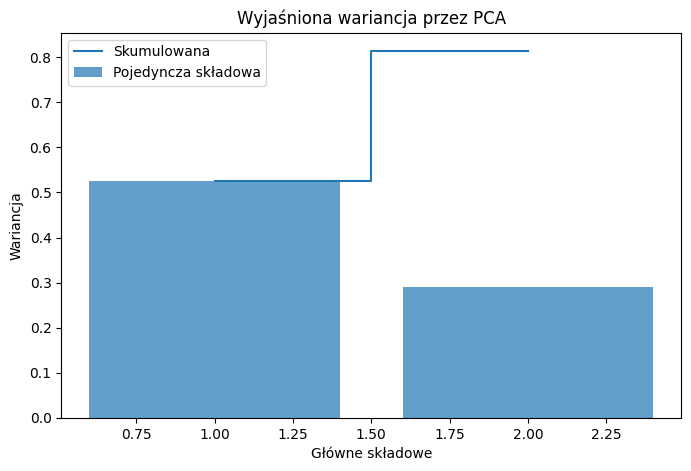

In [5]:
plt.figure(figsize=(8,5))

plt.bar(
    range(1, len(pca.explained_variance_ratio_)+1),
    pca.explained_variance_ratio_,
    alpha=0.7,
    label='Pojedyncza składowa'
)

plt.step(
    range(1, len(pca.explained_variance_ratio_)+1),
    np.cumsum(pca.explained_variance_ratio_),
    where='mid',
    label='Skumulowana'
)

plt.xlabel('Główne składowe')
plt.ylabel('Wariancja')
plt.title('Wyjaśniona wariancja przez PCA')
plt.legend()
plt.show()

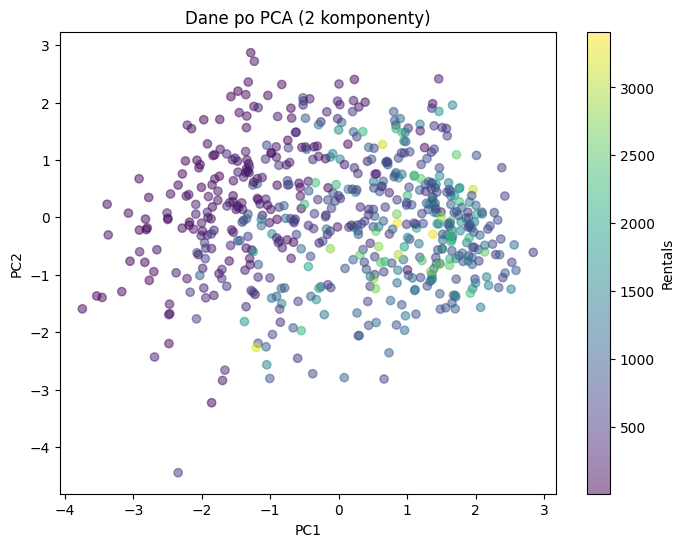

In [6]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_train_pca[:, 0],
    X_train_pca[:, 1],
    c=y_train,
    cmap='viridis',
    alpha=0.5
)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Dane po PCA (2 komponenty)')
plt.colorbar(label='Rentals')
plt.show()

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Skalowanie + PCA
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=4)
X_pca = pca.fit_transform(X_scaled)

df = np.array(X_pca)

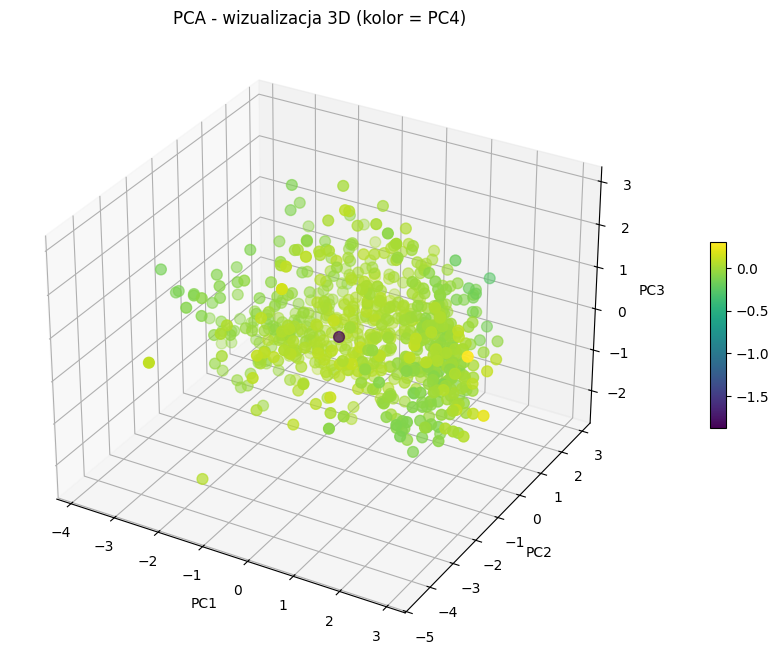

In [8]:
fig = plt.figure(figsize=(8, 16))

ax = fig.add_subplot(111, projection='3d')

img = ax.scatter(
    xs=df[:, 0],
    ys=df[:, 1],
    zs=df[:, 2],
    c=df[:, 3],
    s=60
)

# Colorbar
cax = fig.add_axes([
    ax.get_position().x1 + 0.10,
    ax.get_position().y0 + 0.14,
    0.02,
    ax.get_position().height * 0.3
])

fig.colorbar(img, cax=cax)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('PCA - wizualizacja 3D (kolor = PC4)')

plt.show()

In [9]:
import numpy as np

df = X.values

print('Przed standaryzacją')
print('Średnia:\n', np.mean(df, axis=0))
print('Odchylenie standardowe:\n', np.std(df, axis=0))

# Standaryzacja
df_standardized = (df - np.mean(df, axis=0)) / np.std(df, axis=0)

print('\nPo standaryzacji')
print('Średnia:\n', np.mean(df_standardized, axis=0))
print('Odchylenie standardowe:\n', np.std(df_standardized, axis=0))

Przed standaryzacją
Średnia:
 [0.49538479 0.47435399 0.62789406 0.19048621]
Odchylenie standardowe:
 [0.18292575 0.16284968 0.14233164 0.07744484]

Po standaryzacji
Średnia:
 [-4.17966315e-16  2.91604406e-17 -9.91454980e-16 -2.13843231e-16]
Odchylenie standardowe:
 [1. 1. 1. 1.]


In [12]:
covariance_matrix = np.cov(df_standardized.T)
print(covariance_matrix)

[[ 1.00136986  0.99306005  0.12713686 -0.15816048]
 [ 0.99306005  1.00136986  0.14017982 -0.18389453]
 [ 0.12713686  0.14017982  1.00136986 -0.24882949]
 [-0.15816048 -0.18389453 -0.24882949  1.00136986]]


In [13]:
eigenvalues, eigenvectors = np.linalg.eig(covariance_matrix)

print('Wartości własne:\n', eigenvalues, '\n')
print('Wektory własne:\n', eigenvectors)

Wartości własne:
 [2.10419226 0.00793965 1.14206671 0.75128083] 

Wektory własne:
 [[ 0.66349004  0.70510618  0.24824351  0.03132731]
 [ 0.66799703 -0.70886255  0.22572634  0.01847882]
 [ 0.21915737  0.00537565 -0.6882865   0.69152212]
 [-0.2559902  -0.01761412  0.64318307  0.72143904]]


In [14]:
explained_variance = [round((i/np.sum(eigenvalues)), 3) for i in sorted(eigenvalues, reverse=True)]
print(explained_variance)

[0.525, 0.285, 0.188, 0.002]


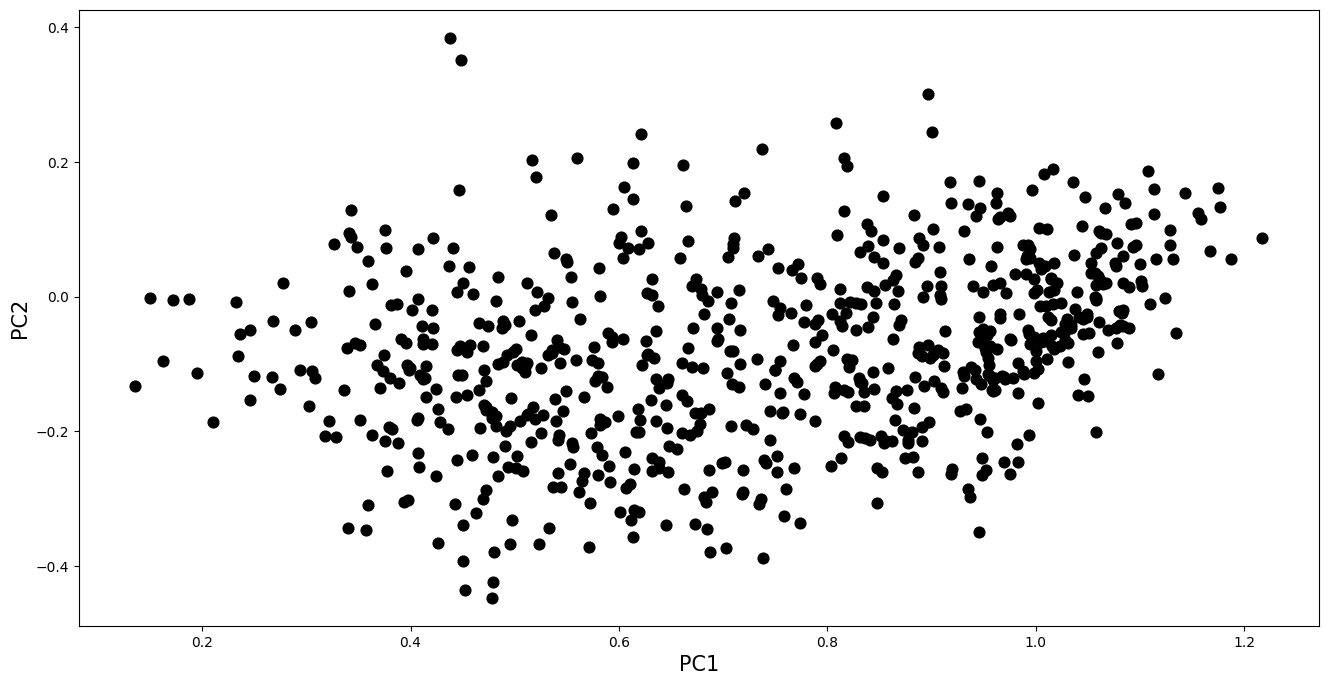

In [15]:
eigenpairs = [(np.abs(eigenvalues[i]), eigenvectors[:, i]) for i in range(len(eigenvalues))]
eigenpairs.sort(key = lambda k: k[0], reverse=True)
w = np.hstack((eigenpairs[0][1][:, np.newaxis],
               eigenpairs[1][1][:, np.newaxis]))
pc1 = df.dot(w.T[0])
pc2 = df.dot(w.T[1])
fig = plt.figure(figsize=(16, 8))
ax = fig.add_subplot(111)
ax.scatter(x=pc1, y=pc2, c='black', s=60)
ax.set_xlabel(xlabel='PC1', rotation=0, loc='center', size=15)
ax.set_ylabel(ylabel='PC2', rotation=90, loc='center', size=15)
plt.show()

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# dane wejściowe
df = bike_data[numeric_features].values

# standaryzacja
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

# PCA
pca = PCA(n_components=4)
df_pca = pca.fit_transform(df_scaled)

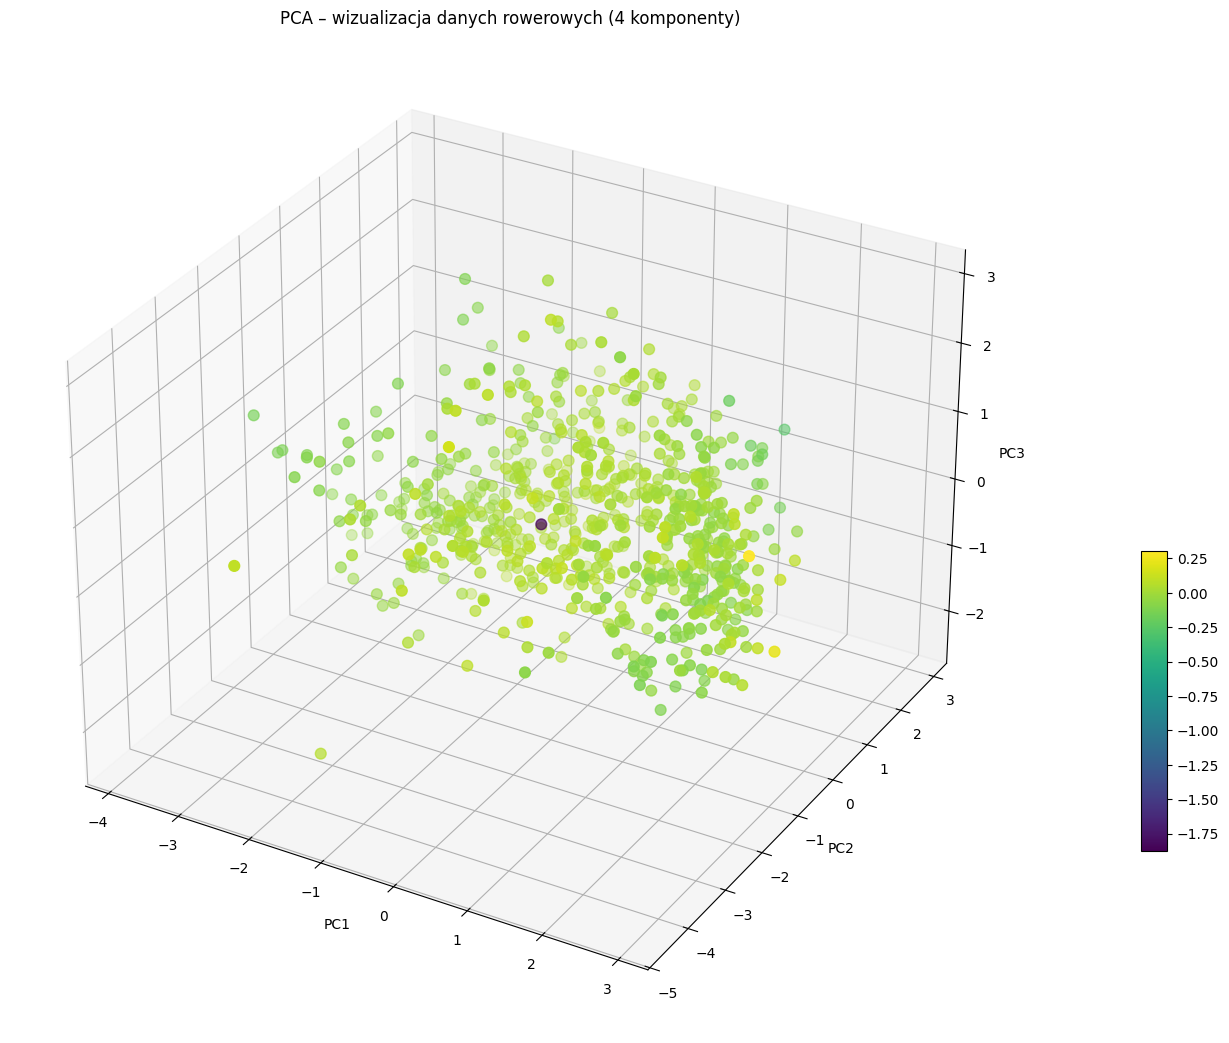

In [18]:
fig = plt.figure(figsize=(13, 13))
ax = fig.add_subplot(111, projection='3d')

img = ax.scatter(
    xs=df_pca[:, 0],   # PC1
    ys=df_pca[:, 1],   # PC2
    zs=df_pca[:, 2],   # PC3
    c=df_pca[:, 3],    # kolor = PC4
    s=60
)

# kolorbar
cax = fig.add_axes([
    ax.get_position().x1 + 0.10,
    ax.get_position().y0 + 0.14,
    0.02,
    ax.get_position().height * 0.3
])

fig.colorbar(img, cax=cax)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('PCA – wizualizacja danych rowerowych (4 komponenty)')

plt.show()

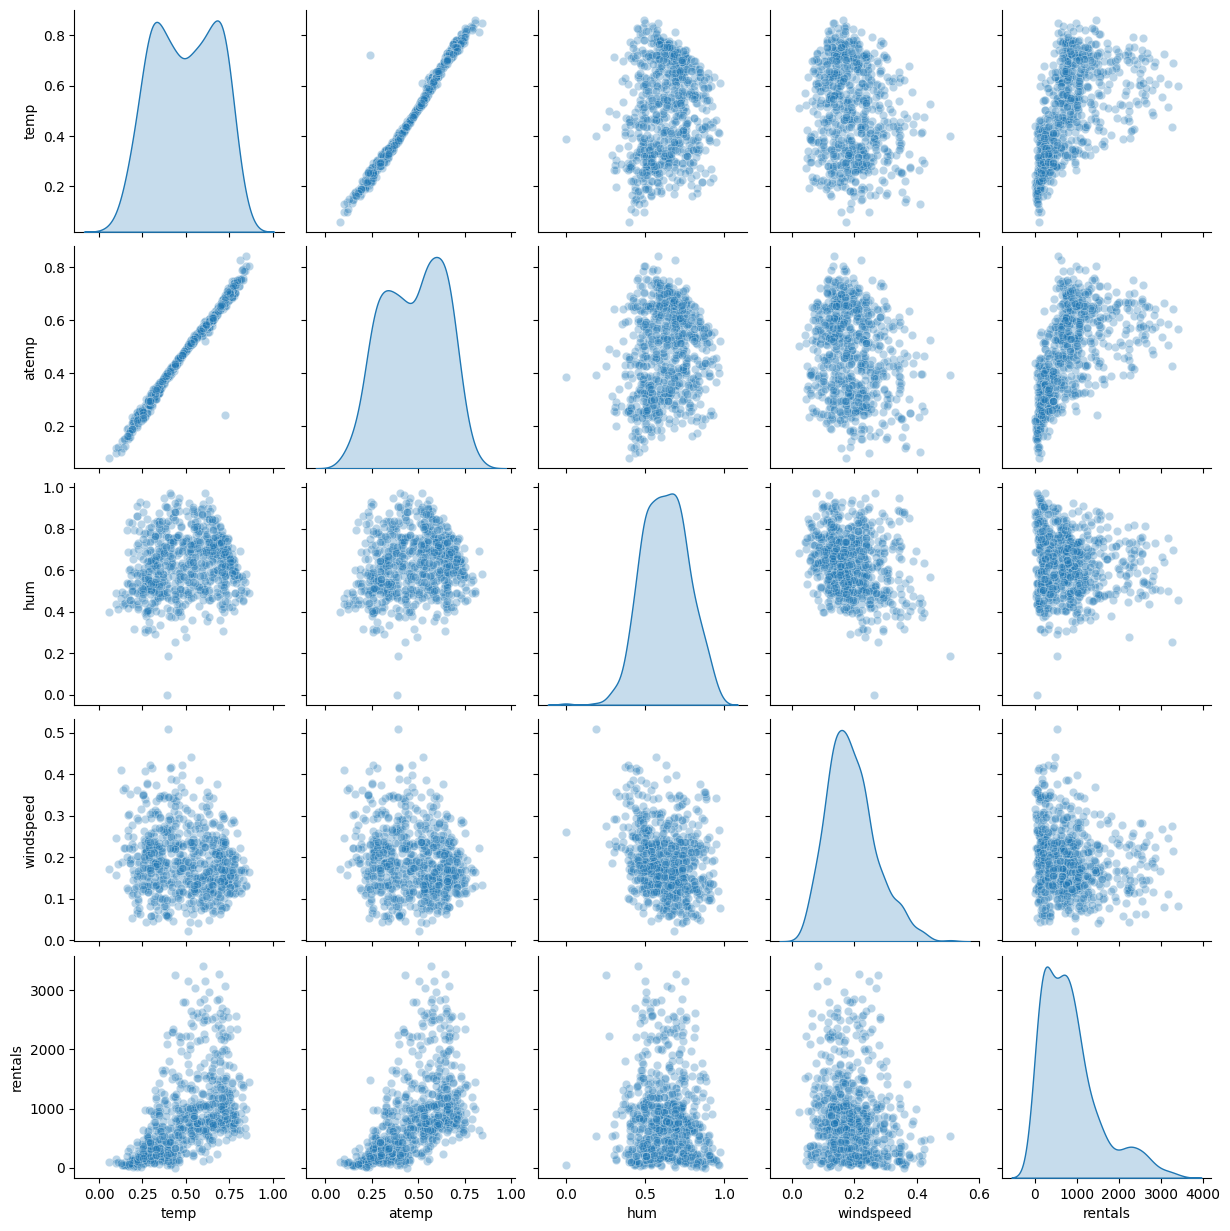

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(
    bike_data[numeric_features + [target]],
    diag_kind='kde',
    plot_kws={'alpha': 0.3}
)

plt.show()

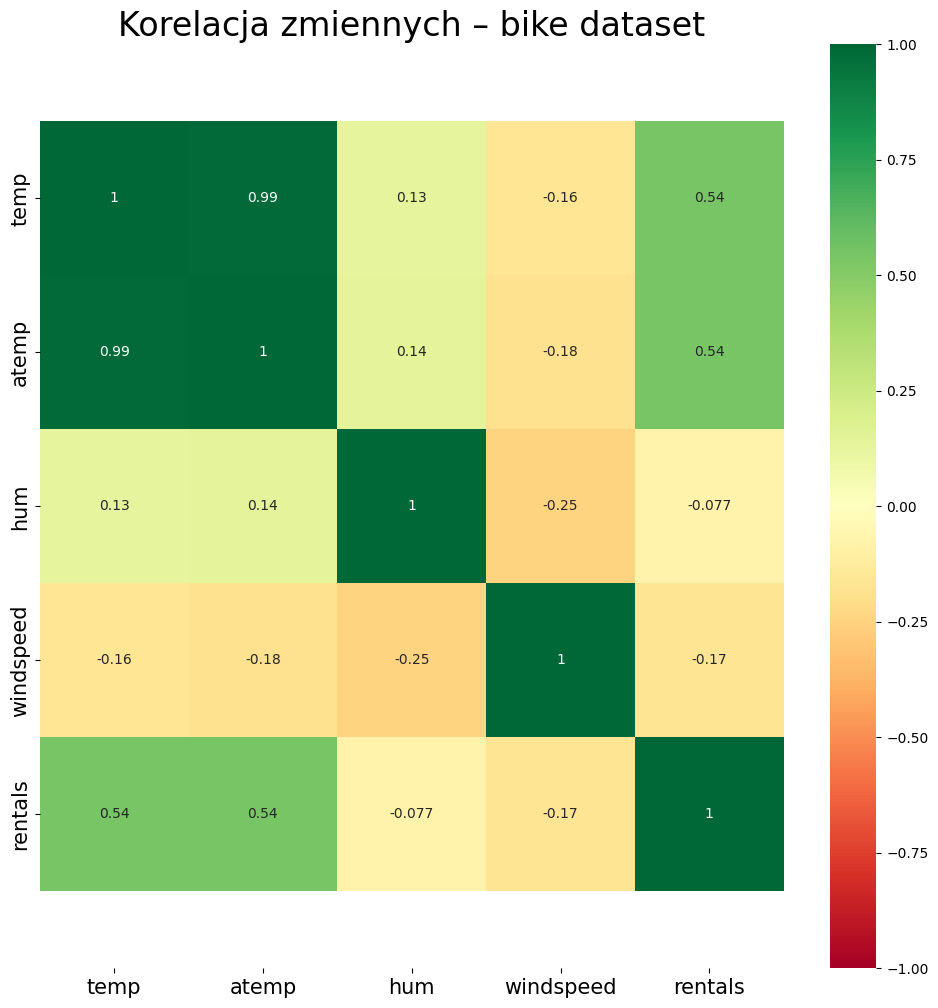

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 12))

ax = sns.heatmap(
    bike_data[numeric_features + [target]].corr(),
    xticklabels=True,
    yticklabels=True,
    cmap='RdYlGn',
    center=0,
    annot=True,
    vmin=-1,
    vmax=1
)

plt.title('Korelacja zmiennych – bike dataset', fontsize=24)

bottom, top = ax.get_ylim()
ax.set_ylim(bottom + 0.5, top - 0.5)

plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

plt.show()

In [22]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# cechy i target
X = bike_data[numeric_features].copy()
y = bike_data[target].copy()

# podział danych
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=42
)

# standaryzacja
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# PCA
pca = PCA(random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)

# DataFrame z PCA + target
train_df = pd.DataFrame(
    X_train_pca,
    columns=[f'PC{i+1}' for i in range(X_train_pca.shape[1])]
)

# dodajemy target (rentals)
train_df['rentals'] = y_train.values

# korelacja
train_df.corr()

,PC1,PC2,PC3,PC4,rentals
PC1,1.000000e+00,1.011283e-16,-4.804775e-17,2.128761e-15,0.464273
PC2,1.011283e-16,1.000000e+00,3.738496e-16,3.720523e-17,-0.237423
PC3,-4.804775e-17,3.738496e-16,1.000000e+00,-8.453423e-16,-0.131457
PC4,2.128761e-15,3.720523e-17,-8.453423e-16,1.000000e+00,0.078123
rentals,4.642731e-01,-2.374231e-01,-1.314568e-01,7.812253e-02,1.000000


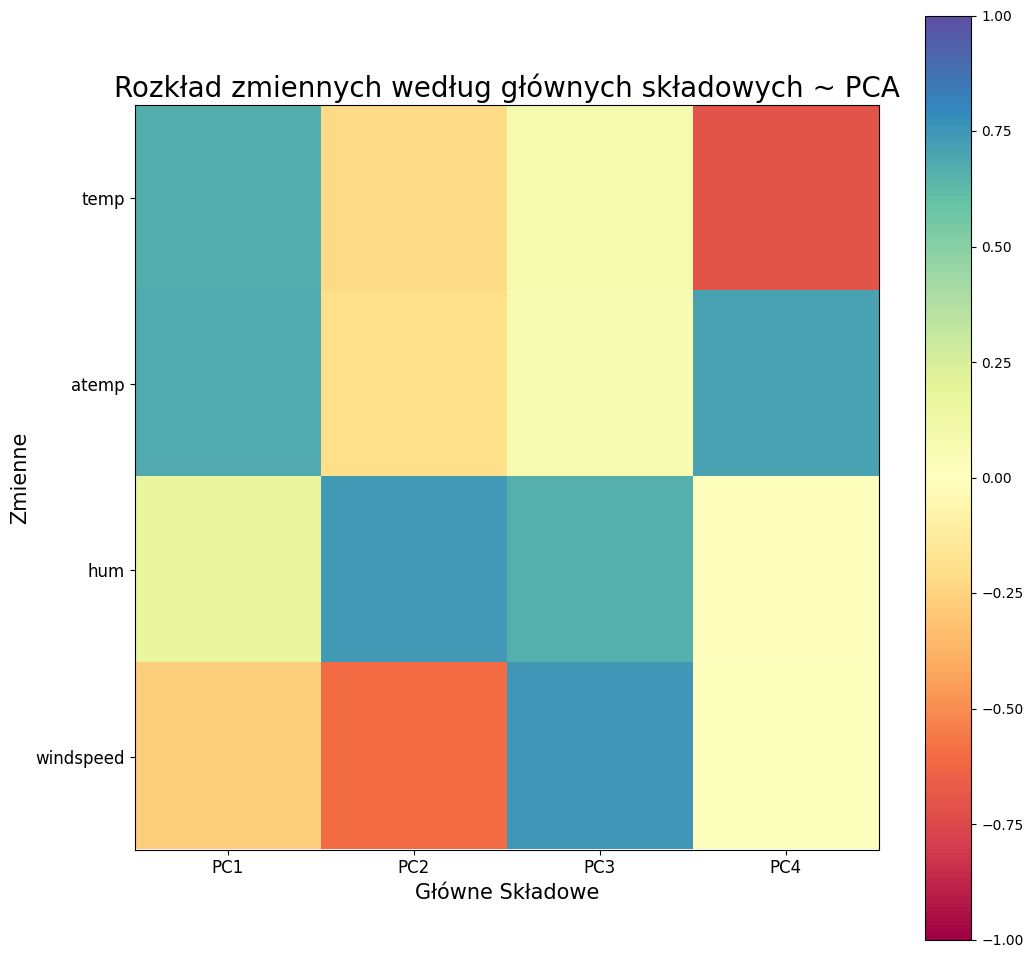

In [23]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(12, 12))

# wykres macierzy komponentów PCA
plt.imshow(pca.components_.T, cmap='Spectral', vmin=-1, vmax=1)

# nazwy zmiennych
plt.yticks(
    range(len(X_train.columns)),
    X_train.columns,
    fontsize=12
)

# liczba komponentów (dynamicznie!)
plt.xticks(
    range(pca.n_components_),
    [f'PC{i+1}' for i in range(pca.n_components_)],
    fontsize=12
)

plt.xlabel('Główne Składowe', fontsize=15)
plt.ylabel('Zmienne', fontsize=15)

plt.title('Rozkład zmiennych według głównych składowych ~ PCA', fontsize=20)

plt.colorbar()
plt.show()

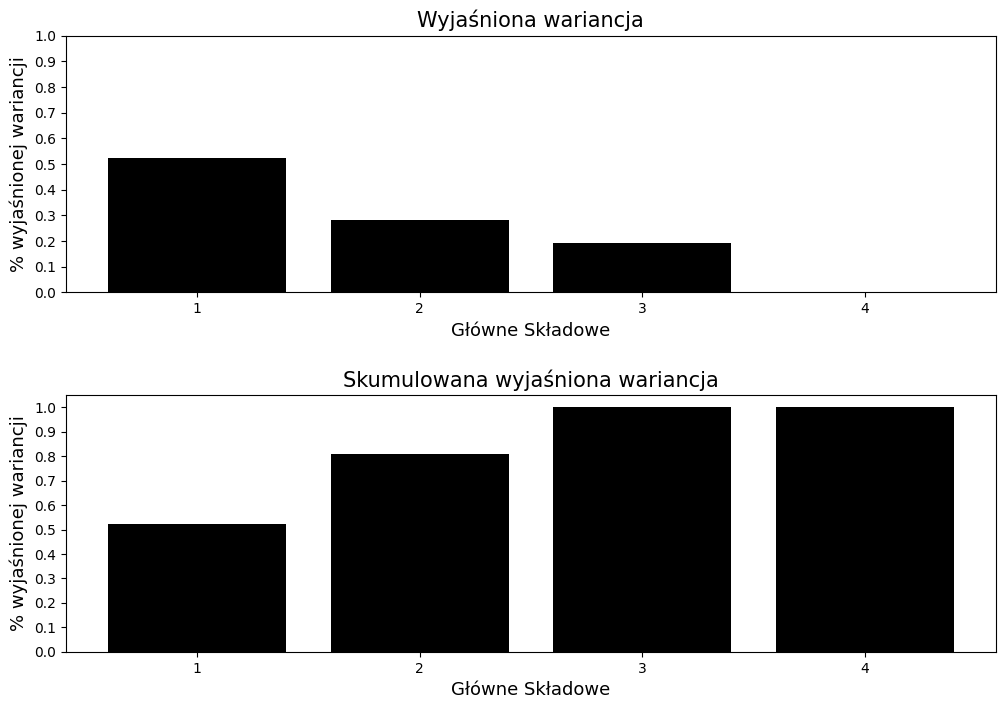

In [24]:
import numpy as np
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12, 8))
fig.subplots_adjust(wspace=.4, hspace=.4)

# --- Wyjaśniona wariancja ---
ax = fig.add_subplot(2, 1, 1)

ax.bar(
    range(1, pca.n_components_ + 1),
    pca.explained_variance_ratio_,
    color='black'
)

ax.set_xticks(range(1, pca.n_components_ + 1))
plt.yticks(np.arange(0, 1.1, 0.1))

plt.title('Wyjaśniona wariancja', fontsize=15)
plt.xlabel('Główne Składowe', fontsize=13)
plt.ylabel('% wyjaśnionej wariancji', fontsize=13)

# --- Skumulowana wariancja ---
ax = fig.add_subplot(2, 1, 2)

ax.bar(
    range(1, pca.n_components_ + 1),
    np.cumsum(pca.explained_variance_ratio_),
    color='black'
)

ax.set_xticks(range(1, pca.n_components_ + 1))
plt.yticks(np.arange(0, 1.1, 0.1))

plt.title('Skumulowana wyjaśniona wariancja', fontsize=15)
plt.xlabel('Główne Składowe', fontsize=13)
plt.ylabel('% wyjaśnionej wariancji', fontsize=13)

plt.show()

In [25]:
cum_explained_var = 0

for i, explained_var in enumerate(pca.explained_variance_ratio_, start=1):
    cum_explained_var += explained_var
    
    print(
        f'Główna składowa: {i}, '
        f'Wyjaśniona wariancja: {np.round(explained_var, 5)}, '
        f'Skumulowana wariancja: {np.round(cum_explained_var, 5)}'
    )

Główna składowa: 1, Wyjaśniona wariancja: 0.52426, Skumulowana wariancja: 0.52426
Główna składowa: 2, Wyjaśniona wariancja: 0.28383, Skumulowana wariancja: 0.80809
Główna składowa: 3, Wyjaśniona wariancja: 0.19111, Skumulowana wariancja: 0.9992
Główna składowa: 4, Wyjaśniona wariancja: 0.0008, Skumulowana wariancja: 1.0


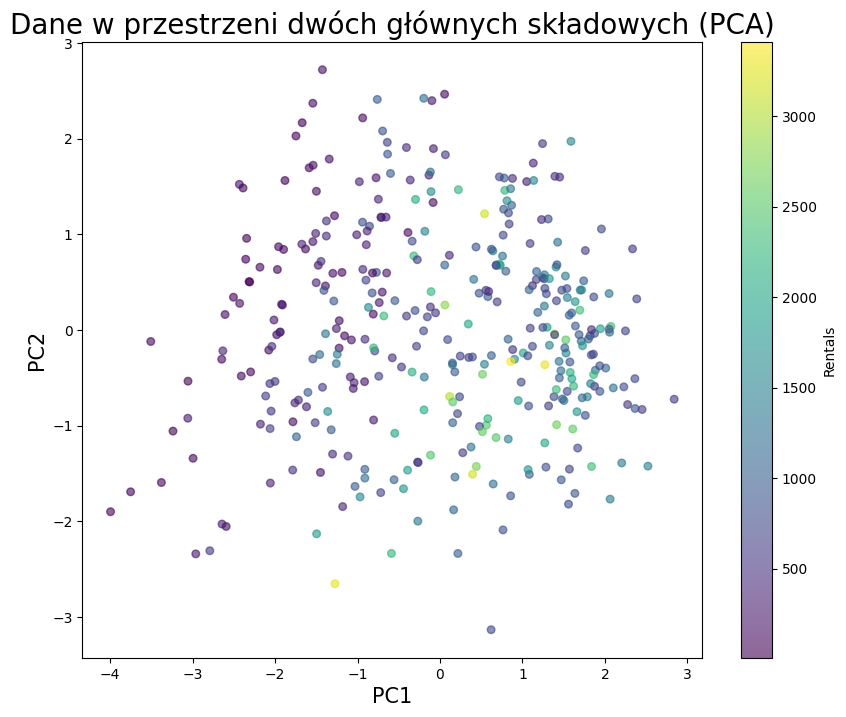

In [28]:
import matplotlib.pyplot as plt
import pandas as pd

# transformacja danych
X_train_pca = pca.transform(X_train_scaled)

# tworzenie DataFrame
df_pca = pd.DataFrame(
    X_train_pca,
    columns=[f'PC{i+1}' for i in range(X_train_pca.shape[1])]
)

# dodanie targetu
df_pca['rentals'] = y_train.reset_index(drop=True)

# wykres
plt.figure(figsize=(10, 8))

plt.scatter(
    df_pca['PC1'],
    df_pca['PC2'],
    c=df_pca['rentals'],
    cmap='viridis',
    alpha=0.6,
    s=30
)

plt.colorbar(label='Rentals')

plt.xlabel('PC1', fontsize=15)
plt.ylabel('PC2', fontsize=15)
plt.title('Dane w przestrzeni dwóch głównych składowych (PCA)', fontsize=20)

plt.show()

In [29]:
import numpy as np
import datetime
from sklearn.linear_model import LinearRegression
from prettytable import PrettyTable

# przygotowanie danych testowych
X_test_scaled = scaler.transform(X_test)
X_test_pca = pca.transform(X_test_scaled)

# funkcja treningu i oceny (REGRESJA)
def train_and_check(Xtrain, Xtest, ytrain, ytest):
    model = LinearRegression()
    
    start = datetime.datetime.now()
    model.fit(Xtrain, ytrain)
    end = datetime.datetime.now()
    
    time = (end - start).microseconds
    
    score = np.round(model.score(Xtest, ytest), 4)
    
    return score, time

# tabela wyników
results = PrettyTable(['Model', 'R^2', 'Czas trenowania (microseconds)'])

# =========================
# MODELE
# =========================

# 1. bez skalowania
not_scaled = train_and_check(X_train, X_test, y_train, y_test)
results.add_row(['Nieskalowane dane', not_scaled[0], not_scaled[1]])

# 2. skalowane dane
scaled = train_and_check(X_train_scaled, X_test_scaled, y_train, y_test)
results.add_row(['Skalowane dane', scaled[0], scaled[1]])

# 3. PCA (wszystkie komponenty)
pc4 = train_and_check(X_train_pca, X_test_pca, y_train, y_test)
results.add_row(['4 PC', pc4[0], pc4[1]])

# 4. 3 komponenty
pc3 = train_and_check(X_train_pca[:, :3], X_test_pca[:, :3], y_train, y_test)
results.add_row(['3 PC', pc3[0], pc3[1]])

# 5. 2 komponenty
pc2 = train_and_check(X_train_pca[:, :2], X_test_pca[:, :2], y_train, y_test)
results.add_row(['2 PC', pc2[0], pc2[1]])

# 6. 1 komponent
pc1 = train_and_check(X_train_pca[:, :1], X_test_pca[:, :1], y_train, y_test)
results.add_row(['1 PC', pc1[0], pc1[1]])

print(results)

+-------------------+--------+--------------------------------+
|       Model       |  R^2   | Czas trenowania (microseconds) |
+-------------------+--------+--------------------------------+
| Nieskalowane dane | 0.2872 |              987               |
|   Skalowane dane  | 0.2872 |              999               |
|        4 PC       | 0.2872 |              996               |
|        3 PC       | 0.3313 |              1000              |
|        2 PC       | 0.3051 |              876               |
|        1 PC       | 0.3147 |              1530              |
+-------------------+--------+--------------------------------+


## Klasyfikacja-PCA

In [38]:
def plot_3d_pca(model, X, y, title):

    import numpy as np
    import matplotlib.pyplot as plt
    from sklearn.preprocessing import StandardScaler
    from sklearn.decomposition import PCA

    # standaryzacja + PCA
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    pca = PCA(n_components=3)
    X_pca = pca.fit_transform(X_scaled)

    # wykres
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')

    img = ax.scatter(
        xs=X_pca[:,0],
        ys=X_pca[:,1],
        zs=X_pca[:,2],
        c=y,
        s=60,
        cmap='viridis'
    )

    # colorbar
    cax = fig.add_axes([
        ax.get_position().x1 + 0.10,
        ax.get_position().y0 + 0.14,
        0.02,
        ax.get_position().height * 0.3
    ])

    fig.colorbar(img, cax=cax)

    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_zlabel("PC3")
    ax.set_title(title)

    plt.show()

#### Logistic Regression + PCA + wizualizacja

Accuracy (LR + PCA): 0.9320388349514563


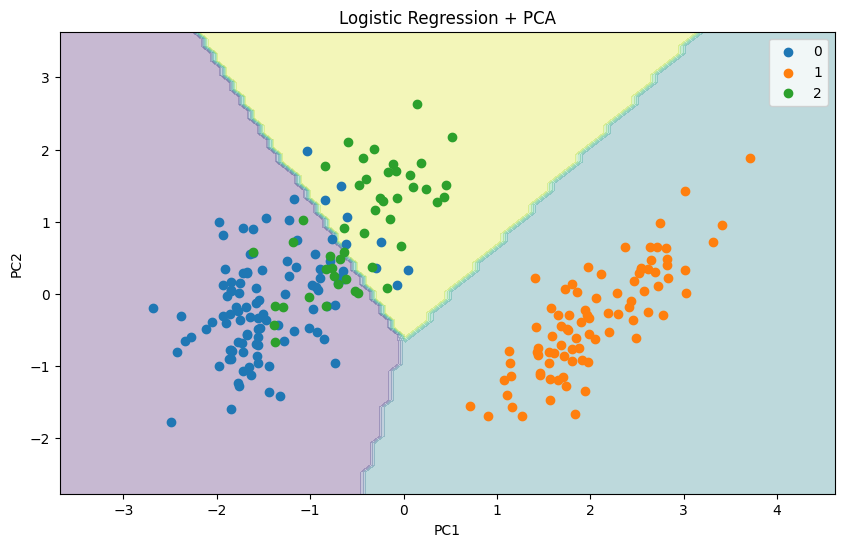

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# pipeline
pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=2)),
    ('model', LogisticRegression(max_iter=500))
])

# trening
pipeline_lr.fit(X_train, y_train)

# predykcja
y_pred_lr = pipeline_lr.predict(X_test)

print("Accuracy (LR + PCA):", accuracy_score(y_test, y_pred_lr))

# =========================
# WIZUALIZACJA
# =========================

# transformacja danych (TYLKO do wizualizacji)
X_train_pca = pipeline_lr.named_steps['pca'].transform(
    pipeline_lr.named_steps['scaler'].transform(X_train)
)

# siatka
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.1),
    np.arange(y_min, y_max, 0.1)
)

grid = np.c_[xx.ravel(), yy.ravel()]

# predykcja na siatce
Z = pipeline_lr.named_steps['model'].predict(grid)
Z = Z.reshape(xx.shape)

# wykres
plt.figure(figsize=(10,6))
plt.contourf(xx, yy, Z, alpha=0.3)

for cls in np.unique(y_train):
    idx = (y_train.values == cls)
    plt.scatter(X_train_pca[idx, 0], X_train_pca[idx, 1], label=str(cls))

plt.title("Logistic Regression + PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()

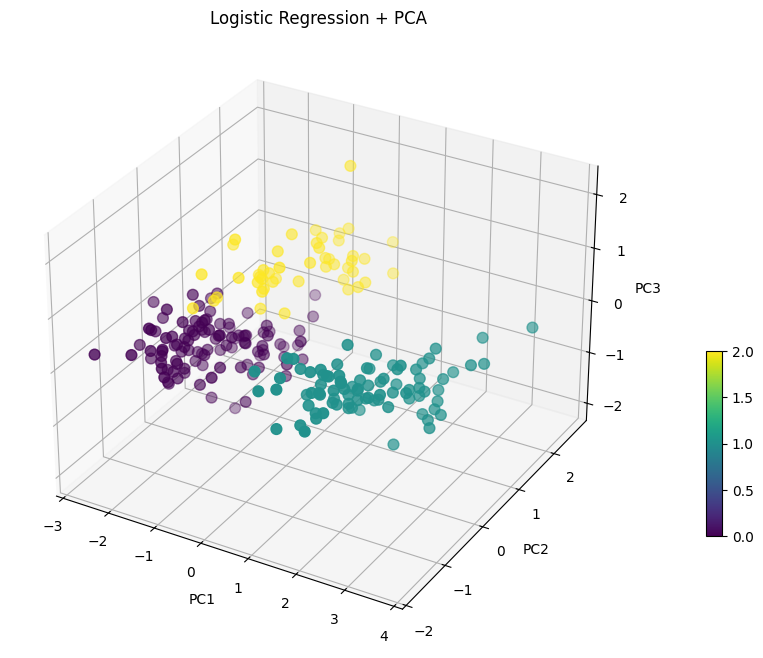

In [39]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression

model_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=3)),
    ('model', LogisticRegression(max_iter=500))
])

model_lr.fit(X_train, y_train)

plot_3d_pca(model_lr, X_train, y_train, "Logistic Regression + PCA")

#### Random Forest + PCA + wizualizacja

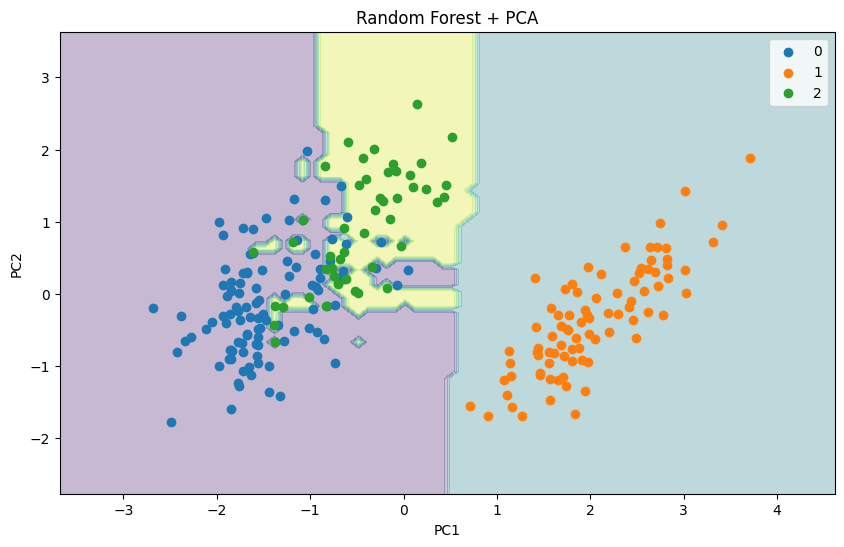

In [36]:
from sklearn.ensemble import RandomForestClassifier

pipeline_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=2)),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])

pipeline_rf.fit(X_train, y_train)

X_pca = pipeline_rf.named_steps['pca'].transform(
    pipeline_rf.named_steps['scaler'].transform(X_train)
)

x_min, x_max = X_pca[:,0].min()-1, X_pca[:,0].max()+1
y_min, y_max = X_pca[:,1].min()-1, X_pca[:,1].max()+1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

grid = np.c_[xx.ravel(), yy.ravel()]
Z = pipeline_rf.named_steps['model'].predict(grid)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10,6))
plt.contourf(xx, yy, Z, alpha=0.3)

for cls in np.unique(y_train):
    idx = (y_train == cls)
    plt.scatter(X_pca[idx,0], X_pca[idx,1], label=str(cls))

plt.title("Random Forest + PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()

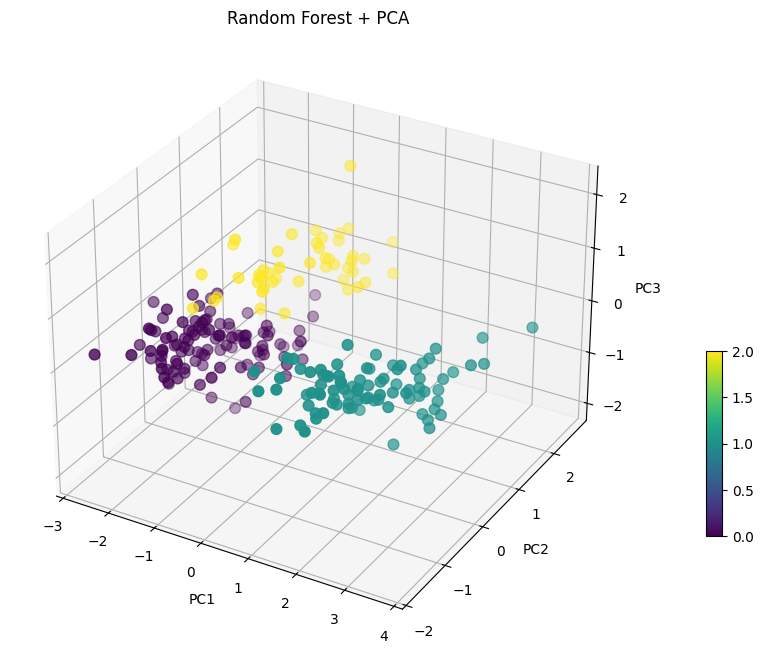

In [40]:
from sklearn.ensemble import RandomForestClassifier

model_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=3)),
    ('model', RandomForestClassifier(n_estimators=100))
])

model_rf.fit(X_train, y_train)

plot_3d_pca(model_rf, X_train, y_train, "Random Forest + PCA")

#### SVM + PCA + wizualizacja

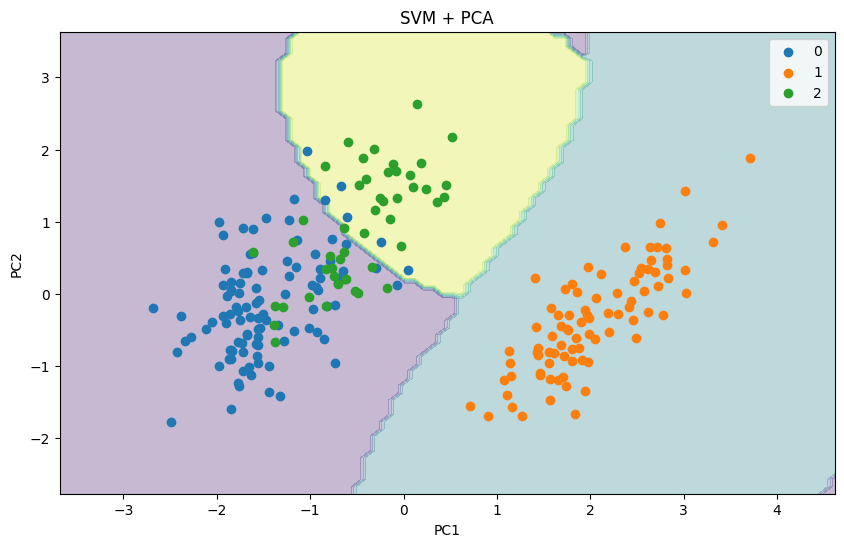

In [37]:
from sklearn.svm import SVC

pipeline_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=2)),
    ('model', SVC(kernel='rbf'))
])

pipeline_svm.fit(X_train, y_train)

X_pca = pipeline_svm.named_steps['pca'].transform(
    pipeline_svm.named_steps['scaler'].transform(X_train)
)

x_min, x_max = X_pca[:,0].min()-1, X_pca[:,0].max()+1
y_min, y_max = X_pca[:,1].min()-1, X_pca[:,1].max()+1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

grid = np.c_[xx.ravel(), yy.ravel()]
Z = pipeline_svm.named_steps['model'].predict(grid)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10,6))
plt.contourf(xx, yy, Z, alpha=0.3)

for cls in np.unique(y_train):
    idx = (y_train == cls)
    plt.scatter(X_pca[idx,0], X_pca[idx,1], label=str(cls))

plt.title("SVM + PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()

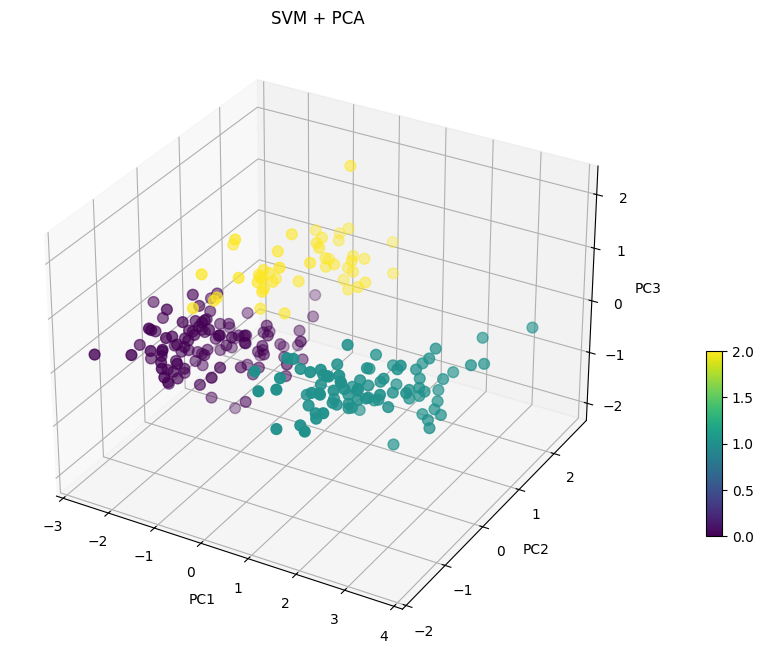

In [41]:
from sklearn.svm import SVC

model_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=3)),
    ('model', SVC(kernel='rbf'))
])

model_svm.fit(X_train, y_train)

plot_3d_pca(model_svm, X_train, y_train, "SVM + PCA")

Dane po czyszczeniu: (342, 4)


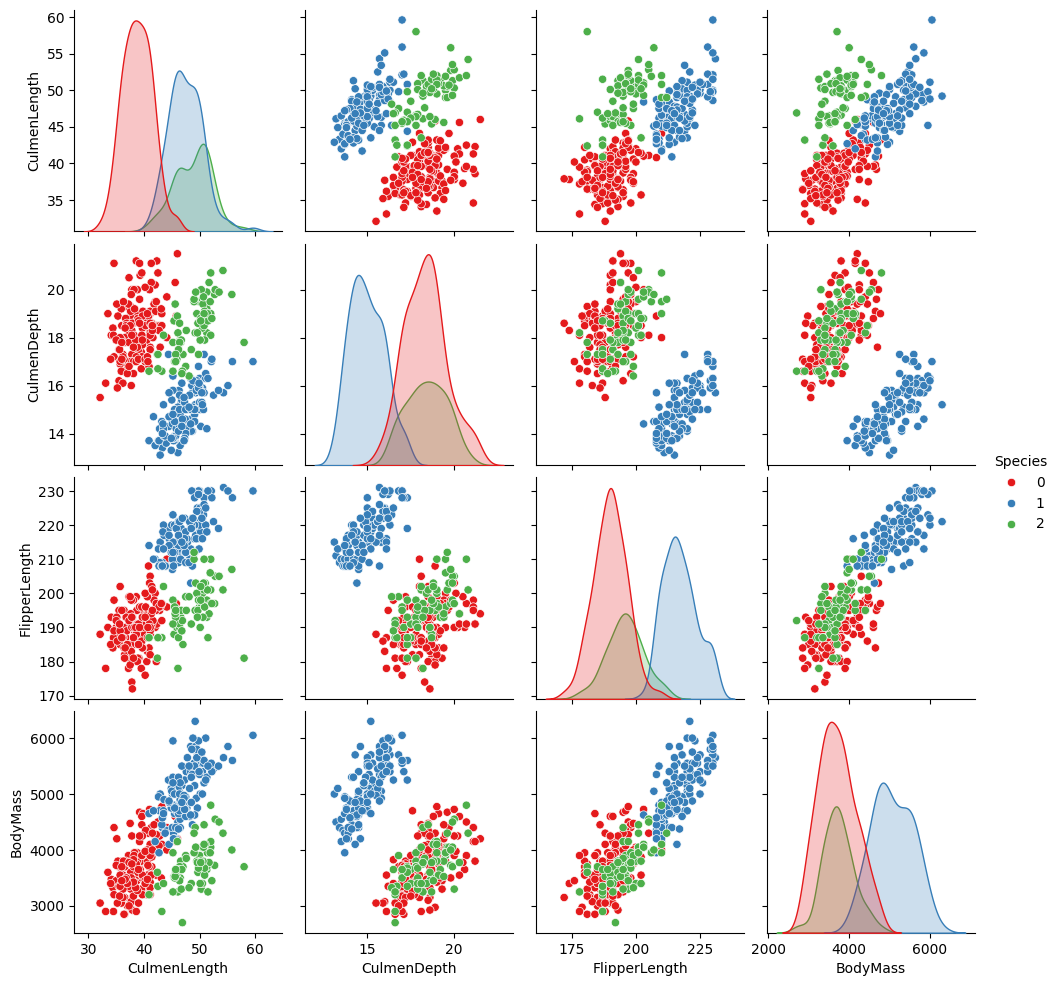

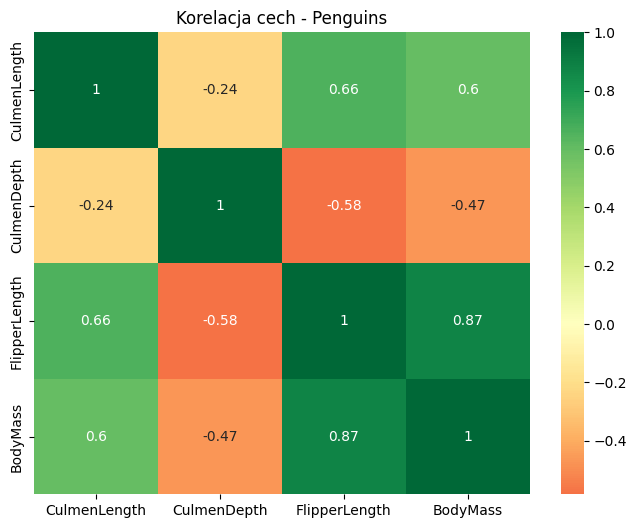

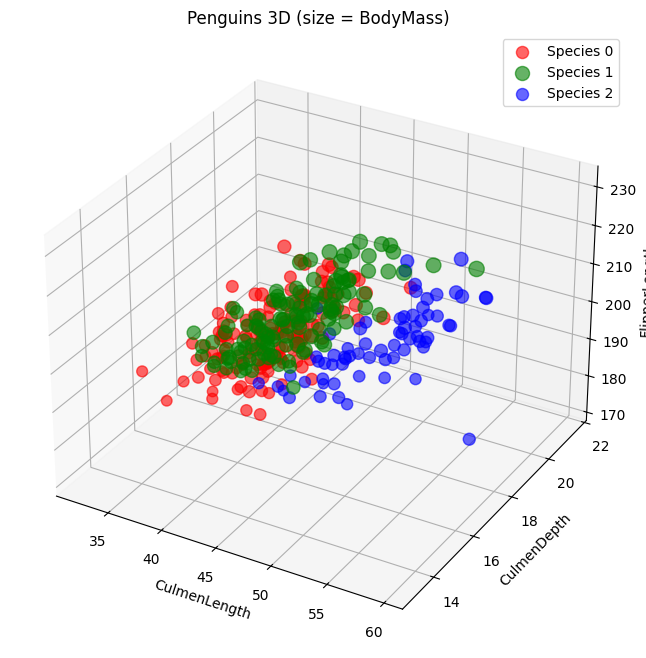

Przed standaryzacją
Średnia:
 [  43.92192982   17.15116959  200.91520468 4201.75438596]
Odchylenie standardowe:
 [  5.45159602   1.97190392  14.04114057 800.78122924]

Po standaryzacji
Średnia:
 [ 1.66208827e-16  4.15522068e-16 -8.31044135e-16  8.31044135e-17]
Odchylenie standardowe:
 [1. 1. 1. 1.]

Macierz kowariancji:
 [[ 1.00293255 -0.23574217  0.65810563  0.59685501]
 [-0.23574217  1.00293255 -0.58556339 -0.47329954]
 [ 0.65810563 -0.58556339  1.00293255  0.87375661]
 [ 0.59685501 -0.47329954  0.87375661  1.00293255]]

Wartości własne:
 [2.76183065 0.7747822  0.36630698 0.10881037]

Wektory własne:
 [[-0.45525033  0.59703114  0.64430115  0.14552311]
 [ 0.40033468  0.79776657 -0.41842724 -0.16798597]
 [-0.57601332  0.0022822  -0.23208397 -0.78379875]
 [-0.54835019  0.08436292 -0.59660012  0.57988211]]

Explained variance: [0.688, 0.193, 0.091, 0.027]


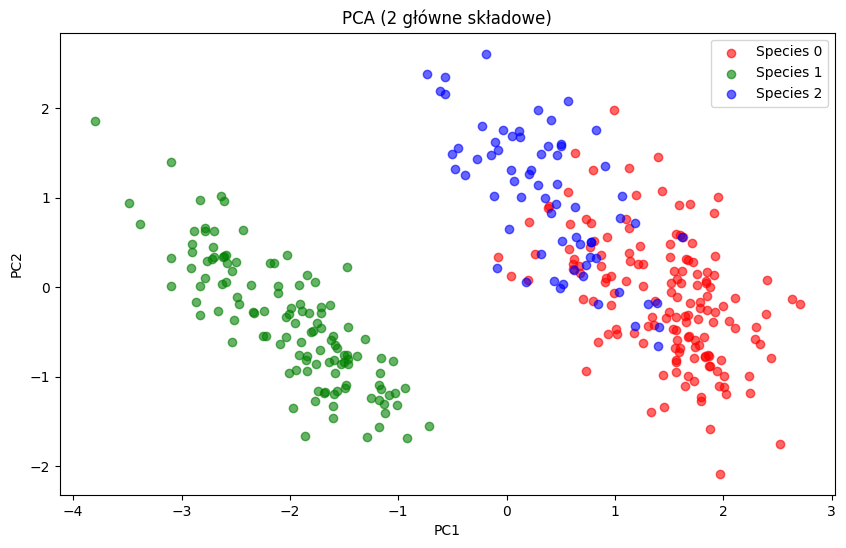

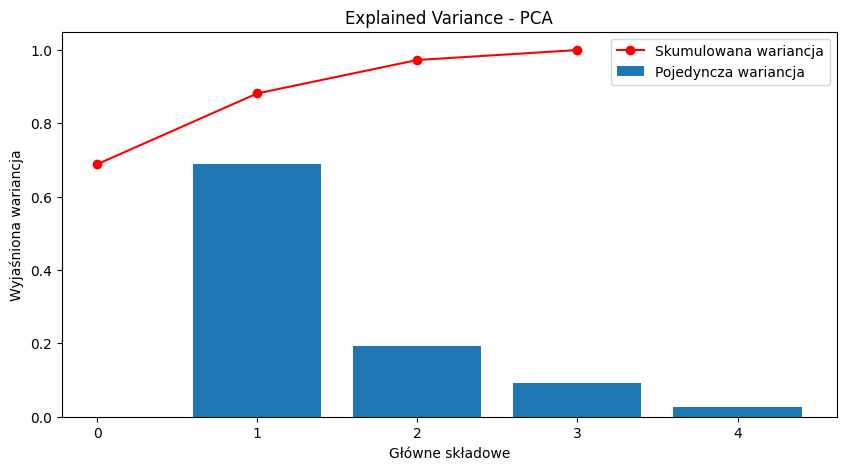

In [43]:
# =========================
# 1. Importy
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# =========================
# 2. Wczytanie danych
# =========================
penguins = pd.read_csv('penguins.csv')

X = penguins.drop("Species", axis=1)
y = penguins["Species"]

# usuwamy brakujące dane
X_clean = X.dropna()
y_clean = y[X_clean.index]

print("Dane po czyszczeniu:", X_clean.shape)

# =========================
# 3. Podstawowa analiza (EDA)
# =========================

# Pairplot
sns.pairplot(pd.concat([X_clean, y_clean], axis=1),
             hue='Species',
             palette='Set1')
plt.show()

# Korelacja
plt.figure(figsize=(8, 6))
sns.heatmap(X_clean.corr(), annot=True, cmap='RdYlGn', center=0)
plt.title('Korelacja cech - Penguins')
plt.show()

# =========================
# 4. Wizualizacja 3D
# =========================
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

for cls, color in zip(sorted(y_clean.unique()), ['red', 'green', 'blue']):
    idx = (y_clean == cls)
    
    ax.scatter(
        X_clean.loc[idx, 'CulmenLength'],
        X_clean.loc[idx, 'CulmenDepth'],
        X_clean.loc[idx, 'FlipperLength'],
        s=X_clean.loc[idx, 'BodyMass'] / 50,
        c=color,
        label=f'Species {cls}',
        alpha=0.6
    )

ax.set_xlabel('CulmenLength')
ax.set_ylabel('CulmenDepth')
ax.set_zlabel('FlipperLength')
ax.set_title('Penguins 3D (size = BodyMass)')
plt.legend()
plt.show()

# =========================
# 5. Standaryzacja
# =========================
df = X_clean.values

print('Przed standaryzacją')
print('Średnia:\n', df.mean(axis=0))
print('Odchylenie standardowe:\n', df.std(axis=0))

df_standardizated = (df - np.mean(df, axis=0)) / np.std(df, axis=0)

print('\nPo standaryzacji')
print('Średnia:\n', df_standardizated.mean(axis=0))
print('Odchylenie standardowe:\n', df_standardizated.std(axis=0))

# =========================
# 6. PCA
# =========================

# macierz kowariancji
covariance_matrix = np.cov(df_standardizated.T)
print("\nMacierz kowariancji:\n", covariance_matrix)

# wartości własne i wektory własne
eigenvalues, eigenvectors = np.linalg.eig(covariance_matrix)

print('\nWartości własne:\n', eigenvalues)
print('\nWektory własne:\n', eigenvectors)

# wyjaśniona wariancja
explained_variance = [
    round((i / np.sum(eigenvalues)), 3)
    for i in sorted(eigenvalues, reverse=True)
]

print("\nExplained variance:", explained_variance)

# =========================
# 7. PCA 2D (wizualizacja)
# =========================

# sortowanie eigenpairs
eigenpairs = [
    (np.abs(eigenvalues[i]), eigenvectors[:, i])
    for i in range(len(eigenvalues))
]
eigenpairs.sort(key=lambda k: k[0], reverse=True)

# wybór 2 głównych składowych
W = np.hstack((
    eigenpairs[0][1][:, np.newaxis],
    eigenpairs[1][1][:, np.newaxis]
))

# rzutowanie danych
pc1 = df_standardizated.dot(W[:, 0])
pc2 = df_standardizated.dot(W[:, 1])

# wykres PCA
plt.figure(figsize=(10, 6))

for cls, color in zip(sorted(y_clean.unique()), ['red', 'green', 'blue']):
    idx = (y_clean == cls)
    plt.scatter(pc1[idx], pc2[idx], c=color, label=f'Species {cls}', alpha=0.6)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA (2 główne składowe)')
plt.legend()
plt.show()

# =========================
# 8. PCA sklearn (do modeli)
# =========================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# wykres wariancji
plt.figure(figsize=(10,5))

plt.bar(range(1, len(pca.explained_variance_ratio_)+1),
        pca.explained_variance_ratio_,
        label='Pojedyncza wariancja')

plt.plot(np.cumsum(pca.explained_variance_ratio_),
         marker='o',
         color='red',
         label='Skumulowana wariancja')

plt.xlabel('Główne składowe')
plt.ylabel('Wyjaśniona wariancja')
plt.title('Explained Variance - PCA')
plt.legend()
plt.show()

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np
import pandas as pd

# =========================
# 1. Dane
# =========================
X = penguins.drop('Species', axis=1).copy()
y = penguins['Species'].copy()

# usuwamy NaN
X_clean = X.dropna()
y_clean = y[X_clean.index]

# =========================
# 2. Podział
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean,
    test_size=0.5,
    random_state=42,
    stratify=y_clean
)

# =========================
# 3. Standaryzacja
# =========================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# =========================
# 4. PCA
# =========================
pca = PCA(random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)

# =========================
# 5. DataFrame PCA + target
# =========================
train_penguins = pd.DataFrame(
    np.concatenate([
        X_train_pca,
        np.array(y_train).reshape(-1, 1)
    ], axis=1)
)

# nazwy kolumn
train_penguins.rename(columns={
    0: 'PC1',
    1: 'PC2',
    2: 'PC3',
    3: 'PC4',
    4: 'Species'
}, inplace=True)

# typy danych
train_penguins[['PC1', 'PC2', 'PC3', 'PC4']] = \
    train_penguins[['PC1', 'PC2', 'PC3', 'PC4']].astype(float)

# =========================
# 6. Korelacja PCA
# =========================
corr_matrix = train_penguins[['PC1', 'PC2', 'PC3', 'PC4']].corr()

print(corr_matrix)

              PC1           PC2           PC3           PC4
PC1  1.000000e+00 -5.772589e-17 -4.698512e-16  9.912933e-16
PC2 -5.772589e-17  1.000000e+00 -6.765703e-16 -3.153274e-15
PC3 -4.698512e-16 -6.765703e-16  1.000000e+00  7.654100e-16
PC4  9.912933e-16 -3.153274e-15  7.654100e-16  1.000000e+00


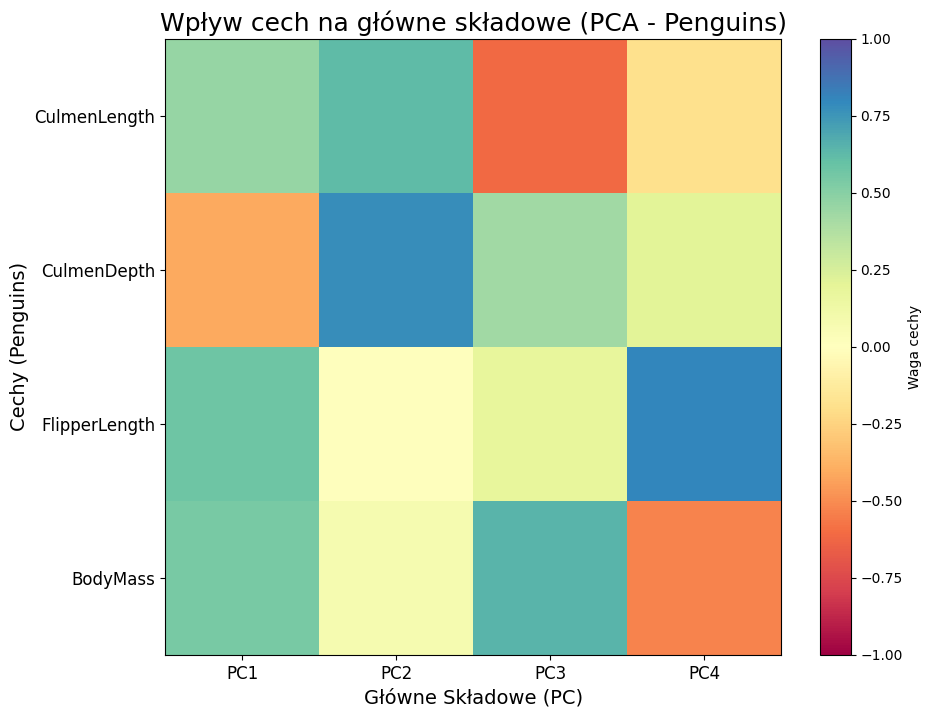

In [45]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))

plt.imshow(
    pca.components_.T,
    cmap='Spectral',
    vmin=-1,
    vmax=1
)

# nazwy cech z penguins
plt.yticks(
    range(len(X_train.columns)),
    X_train.columns,
    fontsize=12
)

# liczba komponentów dynamicznie
plt.xticks(
    range(pca.n_components_),
    [f'PC{i+1}' for i in range(pca.n_components_)],
    fontsize=12
)

plt.xlabel('Główne Składowe (PC)', fontsize=14)
plt.ylabel('Cechy (Penguins)', fontsize=14)
plt.title('Wpływ cech na główne składowe (PCA - Penguins)', fontsize=18)

plt.colorbar(label='Waga cechy')
plt.show()

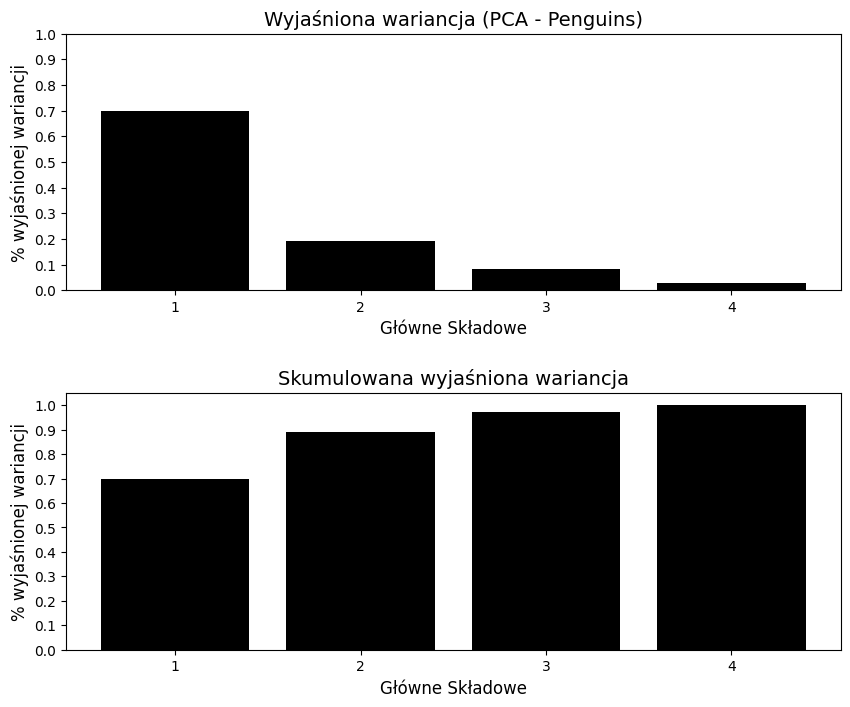

PC1: var=0.69963, cum_var=0.69963
PC2: var=0.19098, cum_var=0.89061
PC3: var=0.08227, cum_var=0.97288
PC4: var=0.02712, cum_var=1.0


In [46]:
import numpy as np
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 8))
fig.subplots_adjust(wspace=0.4, hspace=0.4)

# =========================
# 1. Pojedyncza wariancja
# =========================
ax = fig.add_subplot(2, 1, 1)

ax.bar(
    range(1, pca.n_components_ + 1),
    pca.explained_variance_ratio_,
    color='black'
)

ax.set_xticks(range(1, pca.n_components_ + 1))
plt.yticks(np.arange(0, 1.1, 0.1))

plt.title('Wyjaśniona wariancja (PCA - Penguins)', fontsize=14)
plt.xlabel('Główne Składowe', fontsize=12)
plt.ylabel('% wyjaśnionej wariancji', fontsize=12)

# =========================
# 2. Skumulowana wariancja
# =========================
ax = fig.add_subplot(2, 1, 2)

ax.bar(
    range(1, pca.n_components_ + 1),
    np.cumsum(pca.explained_variance_ratio_),
    color='black'
)

ax.set_xticks(range(1, pca.n_components_ + 1))
plt.yticks(np.arange(0, 1.1, 0.1))

plt.title('Skumulowana wyjaśniona wariancja', fontsize=14)
plt.xlabel('Główne Składowe', fontsize=12)
plt.ylabel('% wyjaśnionej wariancji', fontsize=12)

plt.show()

# =========================
# 3. Wypisanie wartości
# =========================
principal_component = 1
cum_explained_var = 0

for explained_var in pca.explained_variance_ratio_:
    cum_explained_var += explained_var
    
    print(f'PC{principal_component}: '
          f'var={np.round(explained_var, 5)}, '
          f'cum_var={np.round(cum_explained_var, 5)}')
    
    principal_component += 1

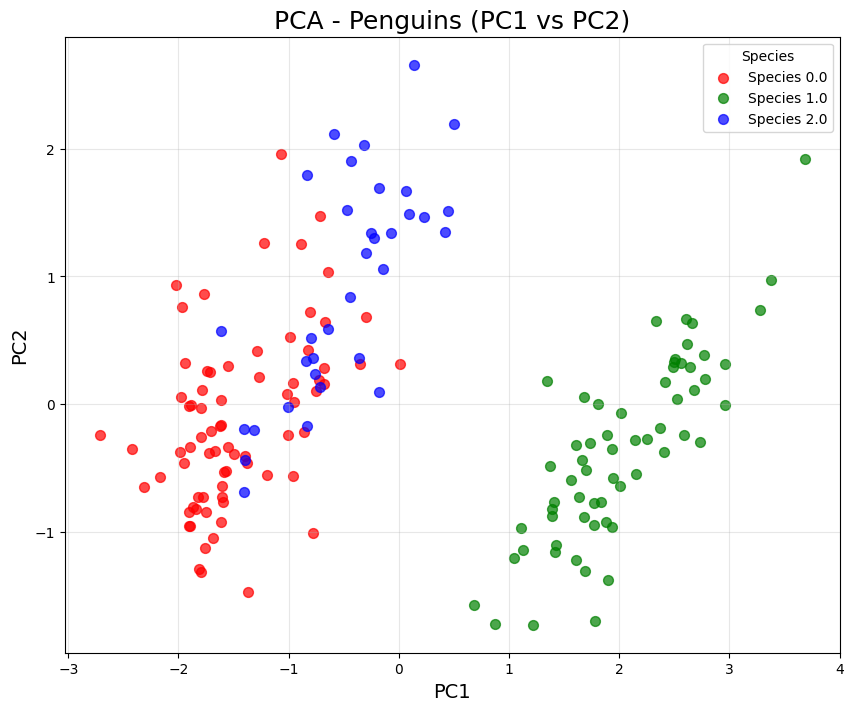

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

colors = ['red', 'green', 'blue']

for cls, color in zip(sorted(train_penguins['Species'].unique()), colors):
    plt.scatter(
        train_penguins.loc[train_penguins['Species'] == cls, 'PC1'],
        train_penguins.loc[train_penguins['Species'] == cls, 'PC2'],
        c=color,
        label=f'Species {cls}',
        s=50,
        alpha=0.7
    )

plt.xlabel('PC1', fontsize=14)
plt.ylabel('PC2', fontsize=14)
plt.title('PCA - Penguins (PC1 vs PC2)', fontsize=18)
plt.legend(title='Species')
plt.grid(alpha=0.3)

plt.show()

In [48]:
from sklearn.linear_model import LogisticRegression
from prettytable import PrettyTable
import datetime
import numpy as np

# =========================
# 1. Transformacja testu
# =========================
X_test_scaled = scaler.transform(X_test)
X_test_pca = pca.transform(X_test_scaled)

# =========================
# 2. Funkcja treningowa
# =========================
def train_and_check(Xtrain, Xtest, ytrain, ytest):
    model = LogisticRegression(max_iter=10000)
    
    start = datetime.datetime.now()
    model.fit(Xtrain, ytrain)
    end = datetime.datetime.now()
    
    time = (end - start).microseconds
    accuracy = np.round(model.score(Xtest, ytest), 4)
    
    return accuracy, time

# =========================
# 3. Tabela wyników
# =========================
results = PrettyTable(['Model', 'Accuracy', 'Czas (μs)'])

# =========================
# 4. Porównania
# =========================

# 1. Surowe dane
raw_data = train_and_check(X_train, X_test, y_train, y_test)
results.add_row(['Raw data', raw_data[0], raw_data[1]])

# 2. Skalowane dane
scaled_data = train_and_check(X_train_scaled, X_test_scaled, y_train, y_test)
results.add_row(['Scaled data', scaled_data[0], scaled_data[1]])

# 3. PCA - wszystkie komponenty
pc_all = train_and_check(X_train_pca, X_test_pca, y_train, y_test)
results.add_row([f'{pca.n_components_} PC', pc_all[0], pc_all[1]])

# 4. PCA - 3 komponenty
if X_train_pca.shape[1] >= 3:
    pc3 = train_and_check(X_train_pca[:, :3], X_test_pca[:, :3], y_train, y_test)
    results.add_row(['3 PC', pc3[0], pc3[1]])

# 5. PCA - 2 komponenty
pc2 = train_and_check(X_train_pca[:, :2], X_test_pca[:, :2], y_train, y_test)
results.add_row(['2 PC', pc2[0], pc2[1]])

# 6. PCA - 1 komponent
pc1 = train_and_check(X_train_pca[:, :1], X_test_pca[:, :1], y_train, y_test)
results.add_row(['1 PC', pc1[0], pc1[1]])

# =========================
# 5. Wyniki
# =========================
print(results)

+-------------+----------+-----------+
|    Model    | Accuracy | Czas (μs) |
+-------------+----------+-----------+
|   Raw data  |  0.9942  |   278911  |
| Scaled data |   1.0    |     0     |
|     4 PC    |   1.0    |     0     |
|     3 PC    |  0.9942  |   15420   |
|     2 PC    |  0.9181  |    2038   |
|     1 PC    |  0.9298  |    2063   |
+-------------+----------+-----------+
